percentile method which is used to detect outliers and proceed the trimming or capping ,
 here capping with percentile is called winsorization

In [36]:
import numpy as np
import pandas as pd

In [37]:
df = pd.read_csv('weight-height.csv')
df.shape


(10000, 3)

In [38]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

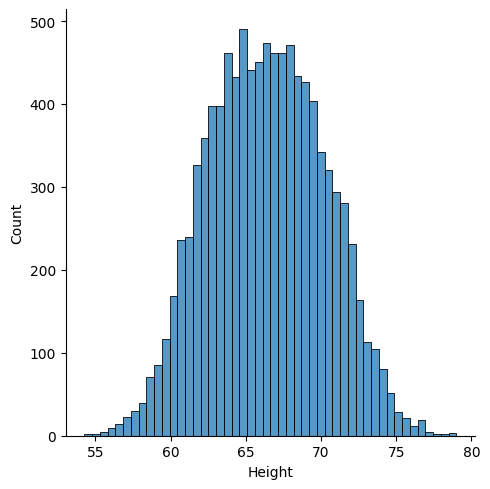

In [39]:
import seaborn as sns

sns.displot(df['Height'])

<Axes: ylabel='Height'>

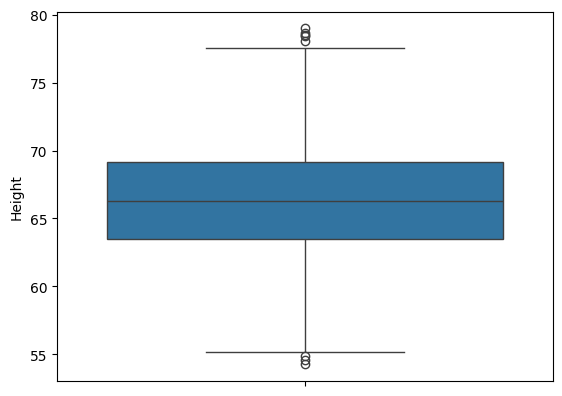

In [40]:
sns.boxplot(df['Height'])

In [41]:
upper=df['Height'].quantile(0.99)
lower=df['Height'].quantile(0.01)
upper,lower

(np.float64(74.7857900583366), np.float64(58.13441158671655))

In [42]:
# trimming of the data

new_df=df[(df['Height']<upper) & (df['Height']>lower)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [43]:
new_df.describe()

,Height,Weight
count,9800.000000,9800.000000
mean,66.364366,161.399489
std,3.645075,30.933549
min,58.134496,77.523774
25%,63.577162,136.322717
50%,66.318070,161.212928
75%,69.119896,186.753317
max,74.785714,249.946283


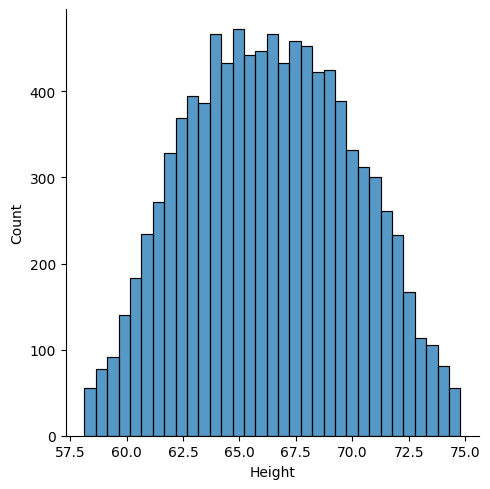

In [44]:
sns.displot(new_df['Height'])

<Axes: xlabel='Height', ylabel='Density'>

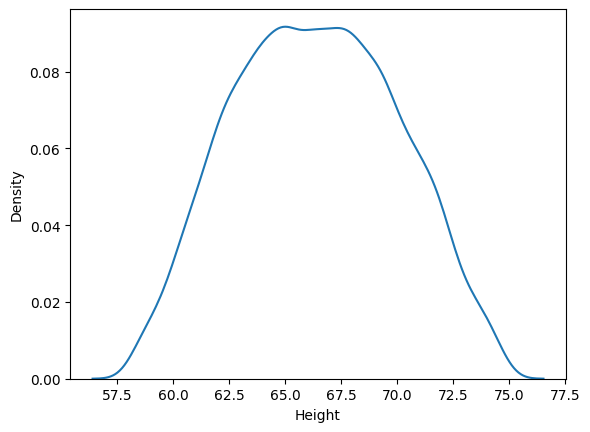

In [45]:
sns.kdeplot(new_df['Height'])

<Axes: ylabel='Height'>

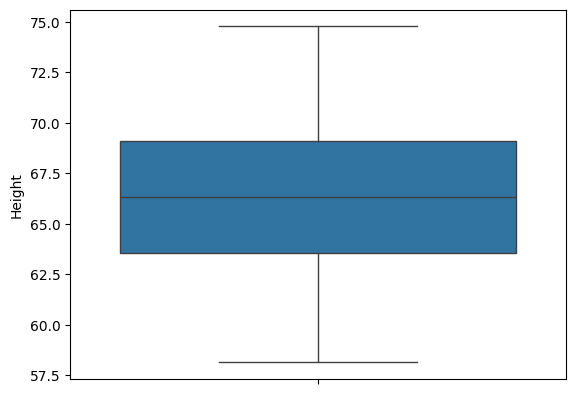

In [46]:
sns.boxplot(new_df['Height'])

In [47]:
df['Height']=np.where(df['Height']>upper,upper,np.where(df['Height']>lower,lower,df['Height']))

In [48]:
df['Height'].describe()

count    10000.000000
mean        58.290849
std          1.663011
min         54.263133
25%         58.134412
50%         58.134412
75%         58.134412
max         74.785790
Name: Height, dtype: float64

C:\Users\mahad\AppData\Local\Temp\ipykernel_12044\741461884.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'],bins=15)


<Axes: xlabel='Height', ylabel='Density'>

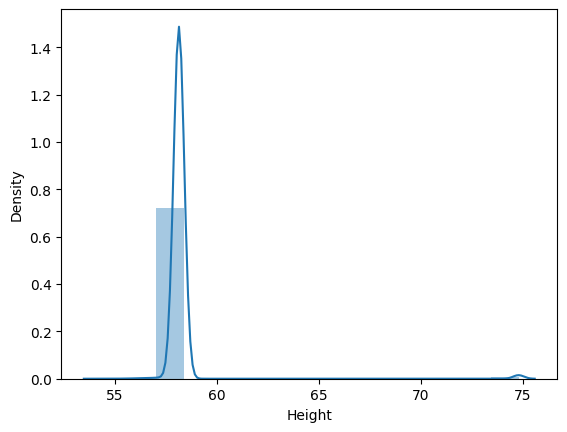

In [49]:
sns.distplot(df['Height'],bins=15)

<Axes: ylabel='Height'>

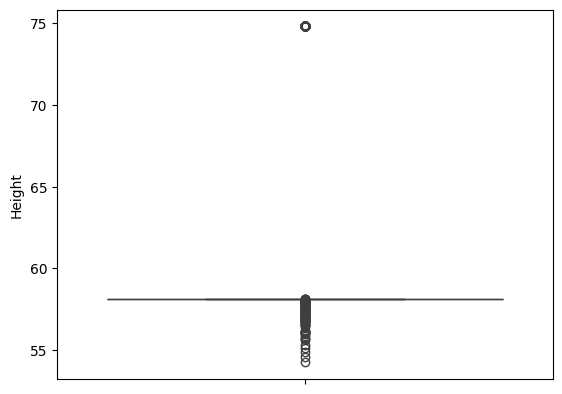

In [50]:
sns.boxplot(df['Height'])